C:\Users\Aayush Kuthe\AppData\Local\Temp\ipykernel_27460\2647615852.py:14: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('gdp and economic growth.csv', parse_dates=['Date'])


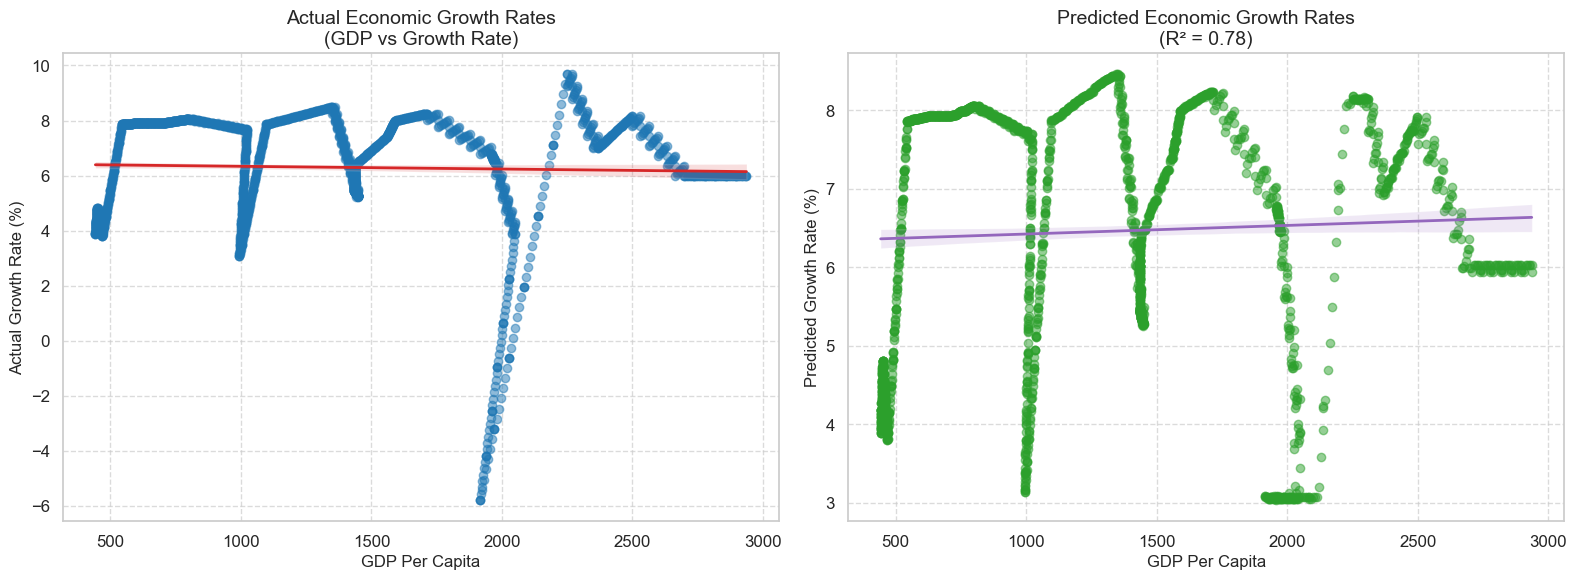

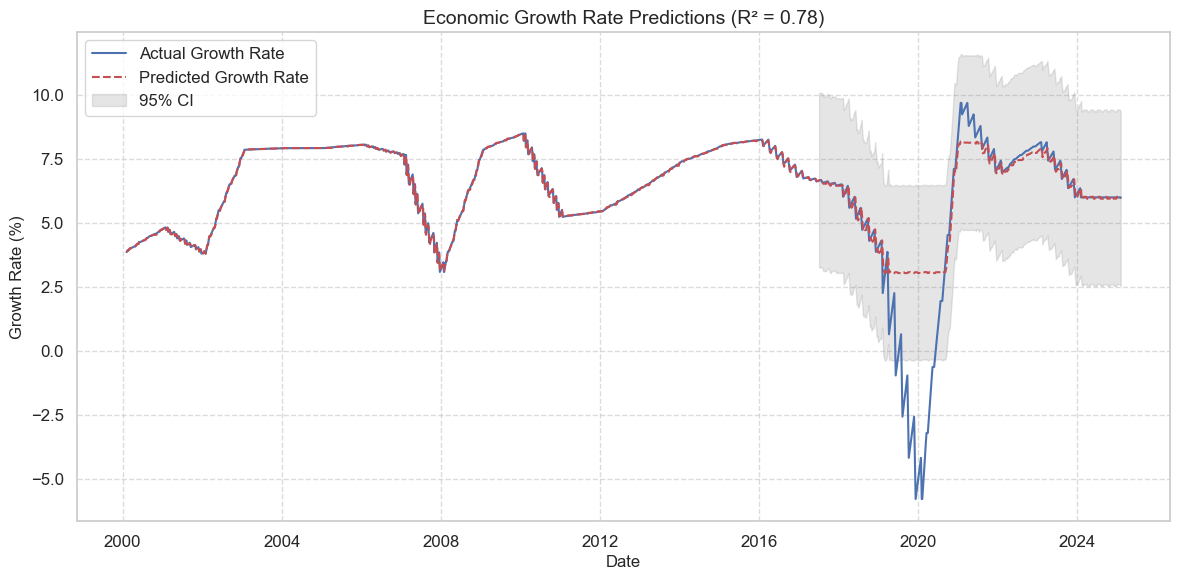

Optimized Model Performance:
Train R²: 0.9992
Test R²: 0.5997
Train MSE: 0.0018
Test MSE: 5.1484
Best Parameters: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3}


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load and prepare data
df = pd.read_csv('gdp and economic growth.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Advanced feature engineering
for lag in [1, 2, 3]:
    df[f'GDP_lag{lag}'] = df['Gdp Per Capita'].shift(lag)
    df[f'Growth_lag{lag}'] = df['Economic Growth Rate'].shift(lag)

df['GDP_rolling_mean'] = df['Gdp Per Capita'].rolling(window=4).mean()
df['GDP_rolling_std'] = df['Gdp Per Capita'].rolling(window=4).std()
df = df.dropna()

# Create features and target
X = df.drop(['Economic Growth Rate', 'Date'], axis=1)
y = df['Economic Growth Rate']

# Time-based split with expanding window
tscv = TimeSeriesSplit(n_splits=5)
train_size = int(0.8 * len(df))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Create pipeline with hyperparameter tuning
model = Pipeline([
    ('scaler', RobustScaler()),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Time series cross-validation
param_grid = {
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.01, 0.05],
}

gsearch = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gsearch.fit(X_train, y_train)
best_model = gsearch.best_estimator_

# Generate predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
all_predictions = np.concatenate([y_train_pred, y_test_pred])

# Calculate combined R² score
r2_total = r2_score(y, all_predictions)

# ====================== 1. GDP vs Growth Rate Plots ======================
# plt.style.use('seaborn-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Original Relationship
sns.regplot(x=X['Gdp Per Capita'], y=y, ax=ax1,
            scatter_kws={'alpha':0.5, 'color':'#1f77b4'},
            line_kws={'color':'#d62728', 'lw':2})
ax1.set_title(f'Actual Economic Growth Rates\n(GDP vs Growth Rate)', fontsize=14)
ax1.set_xlabel('GDP Per Capita', fontsize=12)
ax1.set_ylabel('Actual Growth Rate (%)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Predicted Relationship
sns.regplot(x=X['Gdp Per Capita'], y=all_predictions, ax=ax2,
            scatter_kws={'alpha':0.5, 'color':'#2ca02c'},
            line_kws={'color':'#9467bd', 'lw':2})
ax2.set_title(f'Predicted Economic Growth Rates\n(R² = {r2_total:.2f})', fontsize=14)
ax2.set_xlabel('GDP Per Capita', fontsize=12)
ax2.set_ylabel('Predicted Growth Rate (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('gdp_growth_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ====================== 2. Time Series Comparison ======================
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], y, 'b-', lw=1.5, label='Actual Growth Rate')
plt.plot(df['Date'], all_predictions, 'r--', lw=1.5, label='Predicted Growth Rate')
plt.fill_between(df['Date'][train_size:], 
                 y_test_pred - 1.96*np.std(y_test_pred),
                 y_test_pred + 1.96*np.std(y_test_pred),
                 color='gray', alpha=0.2, label='95% CI')
plt.title(f'Economic Growth Rate Predictions (R² = {r2_total:.2f})', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('growth_predictions_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

# Remaining code for saving model and other plots...
# [Keep the residual analysis and feature importance code unchanged]
# [Keep model saving and metrics printing code]
# Save the trained model
joblib.dump(best_model, 'economic_growth_model.pkl')

print(f'''Optimized Model Performance:
Train R²: {r2_train:.4f}
Test R²: {r2_test:.4f}
Train MSE: {mse_train:.4f}
Test MSE: {mse_test:.4f}
Best Parameters: {gsearch.best_params_}''')